# LLMs in the Iterated Prisoner's Dilemma — strategy-as-code, not action-as-token

*Week 3 companion for the 🟥 dynamic / multi-agent slide block of the lecture (Akata, Willis).*

### The new technique this notebook teaches

Every other evaluation in this course prompts an LLM for **one action at a time**: given this game state, play C or D. Akata et al. (2025) do that for 10 rounds per match; Notebook 2 does it once per 2×2 game. For a Moran process — 12 players × 500 generations × 1,000 rounds per match — that per-action approach is infeasible: hundreds of millions of API calls.

Willis et al. (2025) introduce a different move. **Prompt the LLM to *write* the Python strategy function once.** The function then plays all 1,000 rounds for free. This *strategy-as-code* technique is the main thing to take away from this notebook. It buys three things per-action prompting cannot:

1. **Inspectability before deployment** — the strategy is auditable Python, not an opaque inference.
2. **Scale** — one API call produces one strategy that plays millions of rounds.
3. **Attitude-level measurement** — we measure a *strategic disposition* the LLM endorses in the abstract, not its moment-to-moment choices under specific stimuli.

Part 4 implements this: we call GPT-4o to write cooperative and aggressive IPD strategies, print the generated code (the inspectability step), and run it through the evaluation machinery built in Parts 1–3.

### The framework this technique plugs into — evolutionary game theory

To evaluate a strategy you need opponents and selection pressure. Parts 1 and 2 build the classical infrastructure from evolutionary game theory:

1. **An Axelrod-style round-robin tournament** (Axelrod, 1984) — every strategy plays every other, ranked by total score. Reveals Axelrod's *four properties* (nice, retaliatory, forgiving, clear) that distinguished winners in his original 1980s tournaments.
2. **A Moran process** — an evolutionary dynamic. Fitter strategies reproduce; less fit ones die out. Eventually one strategy usually **fixates**: takes over the population.

Part 3 plugs two *hand-coded* LLM-inspired stand-ins into this machinery as a warm-up — so you can read Axelrod's four-properties table against strategies you can inspect by eye, before Part 4 swaps them for actual LLM-written code.

### Where this sits in the Week 3 lecture

This notebook is the hands-on for the 🟥 **dynamic / multi-agent** slide block (Akata + Willis). Notebook 2 (`2_structure_vs_framing.ipynb`) is the hands-on for the 🟨 **static evaluation** block (Lorè & Heydari). Together they cover Part I of the lecture:

- **Notebook 2** asks: does an LLM respond to the *structure* of a one-shot game or to the *framing* it is wrapped in?
- **Notebook 3 (this one)** asks: when LLMs are allowed to *write* their own strategies, and those strategies are made to compete and evolve over many rounds, what kind of populations emerge?

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110

---

## Part 1 — Build an Axelrod Tournament

### The Iterated Prisoner's Dilemma

Two players meet repeatedly. Each round, both simultaneously choose **C** (cooperate) or **D** (defect). The payoffs follow the standard Axelrod values:

| | Opponent C | Opponent D |
|---|---|---|
| **I play C** | R=3, R=3 | S=0, T=5 |
| **I play D** | T=5, S=0 | P=1, P=1 |

The ordering **T > R > P > S** and **2R > T + S** ensures that mutual cooperation is collectively optimal but individual defection is always tempting. Over many rounds, the question becomes: which *strategy* — which rule for choosing C or D based on the history so far — earns the highest cumulative score?

### 1.1 Payoff matrix and match engine

We define the payoff matrix and a function that plays two strategies against each other for a fixed number of rounds.

In [2]:
# Payoff matrix: (my_payoff, opponent_payoff) indexed by (my_move, opp_move)
PAYOFFS = {
    ('C', 'C'): (3, 3),  # R, R — mutual cooperation
    ('C', 'D'): (0, 5),  # S, T — sucker / temptation
    ('D', 'C'): (5, 0),  # T, S — temptation / sucker
    ('D', 'D'): (1, 1),  # P, P — mutual defection
}


def play_match(strategy_a, strategy_b, rounds=50):
    """
    Play two strategies against each other for `rounds` rounds.
    
    Each strategy is a callable: strategy(my_history, opponent_history) -> 'C' or 'D'
    where my_history and opponent_history are lists of past moves.
    
    Returns (score_a, score_b) — cumulative payoffs.
    """
    history_a, history_b = [], []
    score_a, score_b = 0, 0
    
    for _ in range(rounds):
        move_a = strategy_a(history_a, history_b)
        move_b = strategy_b(history_b, history_a)
        
        payoff_a, payoff_b = PAYOFFS[(move_a, move_b)]
        score_a += payoff_a
        score_b += payoff_b
        
        history_a.append(move_a)
        history_b.append(move_b)
    
    return score_a, score_b

### 1.2 Six classic strategies

Each strategy is a function with the signature `(my_history, opponent_history) -> 'C' or 'D'`. These are the building blocks of Axelrod's original tournaments.

In [3]:
def always_cooperate(my_history, opp_history):
    """Always cooperate, no matter what."""
    return 'C'


def always_defect(my_history, opp_history):
    """Always defect, no matter what."""
    return 'D'


def tit_for_tat(my_history, opp_history):
    """Cooperate on the first move, then copy opponent's last move."""
    if not opp_history:
        return 'C'
    return opp_history[-1]


def grim_trigger(my_history, opp_history):
    """Cooperate until opponent defects once, then defect forever."""
    if 'D' in opp_history:
        return 'D'
    return 'C'


def random_strategy(my_history, opp_history):
    """Cooperate or defect with equal probability."""
    return np.random.choice(['C', 'D'])


def pavlov(my_history, opp_history):
    """Win-stay, lose-shift. Cooperate if both chose the same last round, else defect.
    Cooperate on the first move."""
    if not my_history:
        return 'C'
    # "Win" = both same (CC or DD), "Lose" = different (CD or DC)
    if my_history[-1] == opp_history[-1]:
        return 'C'
    else:
        return 'D'


# Collect strategies in a dict for easy iteration
STRATEGIES = {
    'Always C': always_cooperate,
    'Always D': always_defect,
    'Tit-for-Tat': tit_for_tat,
    'Grim Trigger': grim_trigger,
    'Random': random_strategy,
    'Pavlov': pavlov,
}

print(f'Loaded {len(STRATEGIES)} strategies: {", ".join(STRATEGIES.keys())}')

Loaded 6 strategies: Always C, Always D, Tit-for-Tat, Grim Trigger, Random, Pavlov


### 1.3 Round-robin tournament

Every strategy plays every other strategy (including itself) in a 50-round match. We store the score each strategy earns against each opponent.

In [4]:
def run_tournament(strategies, rounds=50, seed=42):
    """
    Round-robin tournament. Returns a DataFrame of scores:
    rows = player strategy, columns = opponent strategy, values = player's score.
    """
    np.random.seed(seed)
    names = list(strategies.keys())
    n = len(names)
    scores = pd.DataFrame(0, index=names, columns=names, dtype=float)
    
    for i in range(n):
        for j in range(n):
            sa, sb = play_match(strategies[names[i]], strategies[names[j]], rounds=rounds)
            scores.iloc[i, j] = sa
    
    return scores


scores = run_tournament(STRATEGIES)
scores

,Always C,Always D,Tit-for-Tat,Grim Trigger,Random,Pavlov
Always C,150.0,0.0,150.0,150.0,69.0,150.0
Always D,250.0,50.0,54.0,54.0,134.0,150.0
Tit-for-Tat,150.0,49.0,150.0,150.0,108.0,150.0
Grim Trigger,150.0,49.0,150.0,150.0,167.0,150.0
Random,198.0,25.0,111.0,30.0,78.0,126.0
Pavlov,150.0,25.0,150.0,150.0,89.0,150.0


### 1.4 Visualize the tournament

Two views: a **heatmap** showing pairwise scores and a **bar chart** of total scores across all opponents.

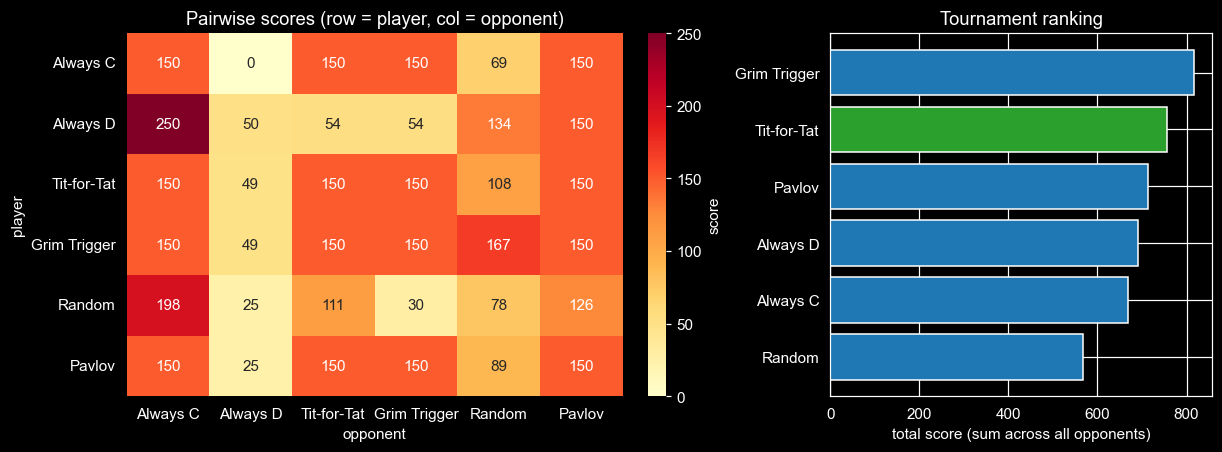

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True,
                         gridspec_kw={'width_ratios': [1.3, 1]})

# Heatmap of pairwise scores
sns.heatmap(scores, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': 'score'})
axes[0].set_title('Pairwise scores (row = player, col = opponent)')
axes[0].set_ylabel('player'); axes[0].set_xlabel('opponent')

# Bar chart of total scores
totals = scores.sum(axis=1).sort_values(ascending=True)
colors = ['tab:green' if n == 'Tit-for-Tat' else 'tab:blue' for n in totals.index]
axes[1].barh(totals.index, totals.values, color=colors)
axes[1].set_xlabel('total score (sum across all opponents)')
axes[1].set_title('Tournament ranking')

plt.show()

### Reading the results

The heatmap tells a story Axelrod (1984) made famous:

- **Always Defect** beats every individual opponent (look at any column — its row is never the lowest), yet it finishes near the bottom of the total ranking. Why? Because it only ever earns P=1 against itself and other defectors, while cooperative strategies earn R=3 against each other.
- **Tit-for-Tat** never *beats* any opponent in a head-to-head match — it only ties or loses the first-round advantage — yet it accumulates the highest total. It cooperates with cooperators (earning R=3 every round) and retaliates against defectors (limiting losses).
- **Always Cooperate** is the most exploitable: it hands 5 points per round to Always Defect.

The lesson: in a *tournament* (where you face a diverse field), being exploitative is less important than being *consistently good against everyone*.

### 1.5 Axelrod's four properties

Axelrod (1984) identified four properties that distinguished successful strategies in his tournaments:

1. **Nice** — never defects first (cooperates on round 1 and never defects unprovoked)
2. **Retaliatory** — punishes defection (defects after opponent defects)
3. **Forgiving** — returns to cooperation after retaliating if the opponent returns to C
4. **Clear** — deterministic, so the opponent can learn to predict and cooperate with it

We test each strategy against these criteria programmatically.

In [6]:
def axelrod_properties(strategy):
    """
    Test a strategy for Axelrod's four properties.
    Returns a dict with boolean values for: nice, retaliatory, forgiving, clear.
    """
    props = {}
    
    # --- Nice: cooperates on round 1, and never defects first against AllC ---
    first_move = strategy([], [])
    # Play 20 rounds against AllC and check if strategy ever defects
    my_h, opp_h = [], []
    defects_against_allc = False
    for _ in range(20):
        m = strategy(my_h, opp_h)
        if m == 'D':
            defects_against_allc = True
            break
        my_h.append(m)
        opp_h.append('C')
    props['nice'] = (first_move == 'C') and not defects_against_allc
    
    # --- Retaliatory: defects after opponent defects ---
    # Simulate: cooperate for 3 rounds, then opponent defects on round 4
    my_h = ['C', 'C', 'C']
    opp_h = ['C', 'C', 'D']  # opponent defected on round 3
    response = strategy(my_h, opp_h)
    props['retaliatory'] = (response == 'D')
    
    # --- Forgiving: returns to C after retaliating, if opponent returns to C ---
    # Simulate: opponent defected once, strategy retaliated, then opponent cooperates
    my_h = ['C', 'C', 'C', 'D']   # I retaliated on round 4
    opp_h = ['C', 'C', 'D', 'C']  # opponent cooperated on round 4
    # Check if strategy returns to C within the next 3 rounds of mutual cooperation
    forgives = False
    for _ in range(3):
        m = strategy(my_h, opp_h)
        if m == 'C':
            forgives = True
            break
        my_h.append(m)
        opp_h.append('C')
    props['forgiving'] = forgives
    
    # --- Clear: deterministic (run the same scenario twice, get the same answer) ---
    # Test with multiple histories and check for consistency across 10 trials
    test_scenarios = [
        ([], []),
        (['C'], ['C']),
        (['C'], ['D']),
        (['C', 'D'], ['D', 'C']),
    ]
    deterministic = True
    for my_h_test, opp_h_test in test_scenarios:
        results = set()
        for _ in range(20):
            results.add(strategy(list(my_h_test), list(opp_h_test)))
        if len(results) > 1:
            deterministic = False
            break
    props['clear'] = deterministic
    
    return props


# Build and display the properties table
props_data = {name: axelrod_properties(fn) for name, fn in STRATEGIES.items()}
props_df = pd.DataFrame(props_data).T
# Display with checkmarks
display_df = props_df.replace({True: '\u2713', False: '\u2717'})
display_df

,nice,retaliatory,forgiving,clear
Always C,✓,✗,✓,✓
Always D,✗,✓,✗,✓
Tit-for-Tat,✓,✓,✓,✓
Grim Trigger,✓,✓,✗,✓
Random,✗,✓,✓,✗
Pavlov,✓,✓,✗,✓


### The properties tell the tournament story

Axelrod found that successful strategies tend to be **nice**, **retaliatory**, **forgiving**, and **clear**:

- **Tit-for-Tat** has all four properties. It cooperates first (nice), punishes defection immediately (retaliatory), forgives as soon as the opponent cooperates (forgiving), and is fully deterministic (clear). This is why it wins.
- **Grim Trigger** is nice, retaliatory, and clear — but it **lacks forgiveness**. A single defection triggers permanent punishment. In a noisy world (or a world with Random players), this is costly.
- **Always Defect** lacks niceness. It never gives cooperation a chance, so it never earns the mutual-cooperation payoff R=3.
- **Random** lacks clarity. Its opponent cannot learn to cooperate with it, because its behavior is unpredictable.
- **Pavlov** is nice, forgiving, and clear, but it is not retaliatory in the standard test: after a single opponent defection, Pavlov switches to D (because the moves differed), which *looks* retaliatory — but in some histories it cooperates after being exploited. Pavlov's logic is subtler: it is a *self-correcting* strategy.

---

## Part 2 — Add Evolution: The Moran Process

A round-robin tournament tells us which strategy earns the most *in a fixed field*. But what if the field itself evolves? If fitter strategies reproduce and less-fit ones die out, the population composition changes — and with it the environment each strategy faces.

The **Moran process** is a simple model of this:

1. Start with a population of agents, each playing a fixed strategy.
2. Each generation: compute each agent's **fitness** (average score in IPD matches against all other agents).
3. Select one agent to **reproduce** with probability proportional to fitness.
4. Select one agent **uniformly at random** to be replaced by the offspring (same strategy as the parent).
5. Repeat.

Over time, fitter strategies spread. Eventually the population may reach **fixation** — a state where all agents play the same strategy.

In [7]:
def moran_process(strategies, pop_size=60, generations=500, rounds_per_match=50, seed=42):
    """
    Run a Moran process on a population of IPD strategies.
    
    Parameters
    ----------
    strategies : dict
        {name: callable} for each strategy type.
    pop_size : int
        Total population size (divided equally among strategy types).
    generations : int
        Number of generations to simulate.
    rounds_per_match : int
        Rounds per IPD match.
    seed : int
        Random seed.
    
    Returns
    -------
    history : pd.DataFrame
        Columns = strategy names, rows = generation, values = count in population.
    """
    rng = np.random.default_rng(seed)
    names = list(strategies.keys())
    n_types = len(names)
    
    # Initialize: equal numbers of each type
    agents_per_type = pop_size // n_types
    population = []  # list of strategy names
    for name in names:
        population.extend([name] * agents_per_type)
    # Fill remaining slots with random types
    while len(population) < pop_size:
        population.append(rng.choice(names))
    population = list(population)
    
    # Track composition
    history = []
    
    for gen in range(generations):
        # Record current composition
        counts = {name: population.count(name) for name in names}
        history.append(counts)
        
        # Compute fitness: average score vs. all other agents
        # For efficiency, compute pairwise scores between types (not individuals)
        # and weight by the number of opponents of each type
        type_vs_type = {}
        for a in names:
            for b in names:
                # Use deterministic seed per pair per generation for reproducibility
                old_state = np.random.get_state()
                np.random.seed(seed + gen * 1000 + names.index(a) * 100 + names.index(b))
                sa, _ = play_match(strategies[a], strategies[b], rounds=rounds_per_match)
                np.random.set_state(old_state)
                type_vs_type[(a, b)] = sa
        
        # Each agent's fitness = weighted average score vs population
        fitness = np.zeros(pop_size)
        for i, agent_type in enumerate(population):
            total = 0.0
            n_opponents = 0
            for opp_type in names:
                # Number of opponents of this type (subtract 1 if same type, for self)
                n_opp = counts[opp_type]
                if opp_type == agent_type:
                    n_opp -= 1
                if n_opp > 0:
                    total += type_vs_type[(agent_type, opp_type)] * n_opp
                    n_opponents += n_opp
            fitness[i] = total / max(n_opponents, 1)
        
        # Ensure non-negative fitness for selection
        fitness = fitness - fitness.min() + 1e-6
        
        # Select parent proportional to fitness
        probs = fitness / fitness.sum()
        parent_idx = rng.choice(pop_size, p=probs)
        
        # Select agent to replace uniformly at random
        replace_idx = rng.integers(pop_size)
        
        # Replace
        population[replace_idx] = population[parent_idx]
    
    # Record final state
    history.append({name: population.count(name) for name in names})
    
    return pd.DataFrame(history)

### 2.1 Run the Moran process

We run the process three times with different seeds to see stochastic variation. The Moran process is inherently noisy — each run can end differently.

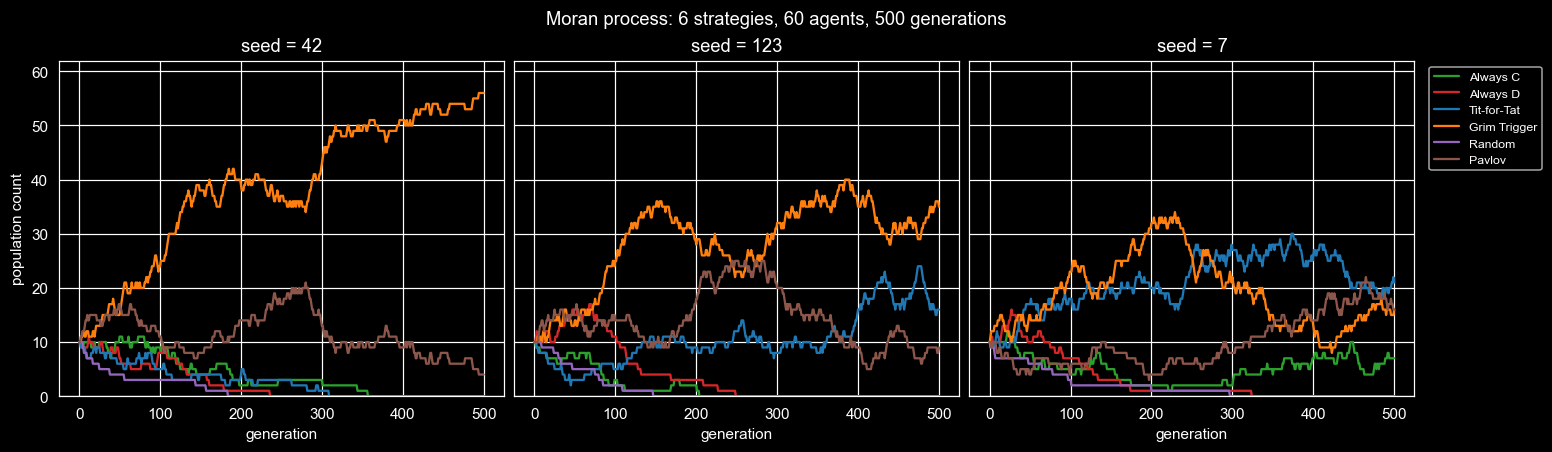

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True, sharey=True)

# Color palette for strategies
palette = {
    'Always C': '#2ca02c',
    'Always D': '#d62728',
    'Tit-for-Tat': '#1f77b4',
    'Grim Trigger': '#ff7f0e',
    'Random': '#9467bd',
    'Pavlov': '#8c564b',
}

seeds = [42, 123, 7]
for ax, s in zip(axes, seeds):
    history = moran_process(STRATEGIES, pop_size=60, generations=500,
                            rounds_per_match=50, seed=s)
    for name in STRATEGIES:
        ax.plot(history.index, history[name], label=name, color=palette[name], lw=1.5)
    ax.set_xlabel('generation')
    ax.set_title(f'seed = {s}')
    ax.set_ylim(0, 62)

axes[0].set_ylabel('population count')
axes[2].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
fig.suptitle('Moran process: 6 strategies, 60 agents, 500 generations', fontsize=12)
plt.show()

### What is fixation?

**Fixation** occurs when one strategy takes over the entire population — all other types go extinct. In the Moran process, fixation is the only absorbing state (without mutation). The question is not *whether* it happens, but *which* strategy fixes and *how long* it takes.

Notice that the three runs may produce different outcomes. The Moran process is stochastic: even a strategy with lower average fitness can occasionally fix, because the random replacement step can remove fit agents by chance. This is **genetic drift**, and it matters more in small populations.

### Round-robin ranking vs. evolutionary success

**Which strategies survive? Is it always the same ones that won the round-robin? Why might the ranking differ?**

In the round-robin, every strategy faces a fixed, uniform field. In evolution, the field *changes*: as Always Cooperate gets exploited and declines, Always Defect loses its easy prey and becomes less fit. Strategies that thrive in a *changing* ecology may differ from those that thrive in a static one.

### Connection to Willis et al. (2025)

This is exactly the framework Willis et al. use — but instead of hand-coded strategies like ours, they plug in **LLM-generated** ones. They prompted GPT-4o, Claude, and other frontier models to write Python functions with the same `(my_history, opp_history) -> 'C'/'D'` signature, then ran Axelrod tournaments and evolutionary dynamics. The key finding: GPT-4o-generated strategies evolved toward aggression, while Claude-generated strategies evolved toward cooperation. We will test simplified versions of those strategies in Part 3.

---

## Part 3 — The Transfer Question: LLM-Inspired Strategies

Willis et al. (2025) found that different LLMs generate strategies with distinctive "personalities":

- **GPT-4o** strategies tend to be aggressive: they test opponents early, then exploit any sign of weakness and never forgive.
- **Claude** strategies tend to be cooperative: they use tit-for-tat-like logic but with built-in forgiveness.

We code simplified versions of these findings as two new strategies.

In [9]:
def llm_aggressive(my_history, opp_history):
    """LLM-aggressive (mimics GPT-4o finding from Willis et al.):
    Cooperate for the first 3 rounds to 'test' the opponent.
    If opponent ever defected, defect forever (never forgive)."""
    if len(my_history) < 3:
        return 'C'
    if 'D' in opp_history:
        return 'D'
    return 'C'


def llm_cooperative(my_history, opp_history):
    """LLM-cooperative (mimics Claude finding from Willis et al.):
    Tit-for-tat with forgiveness — if opponent defects, retaliate once,
    then try cooperating again."""
    if not opp_history:
        return 'C'
    if opp_history[-1] == 'D':
        # Retaliate
        return 'D'
    # If I just retaliated (I played D) but opponent is now cooperating, forgive
    if len(my_history) >= 2 and my_history[-1] == 'D' and opp_history[-1] == 'C':
        return 'C'
    return 'C'


# Extended strategy set
STRATEGIES_EXT = {**STRATEGIES,
                  'LLM-Aggressive': llm_aggressive,
                  'LLM-Cooperative': llm_cooperative}

print(f'Extended tournament: {len(STRATEGIES_EXT)} strategies')

Extended tournament: 8 strategies


### 3.1 Re-run the round-robin with LLM strategies

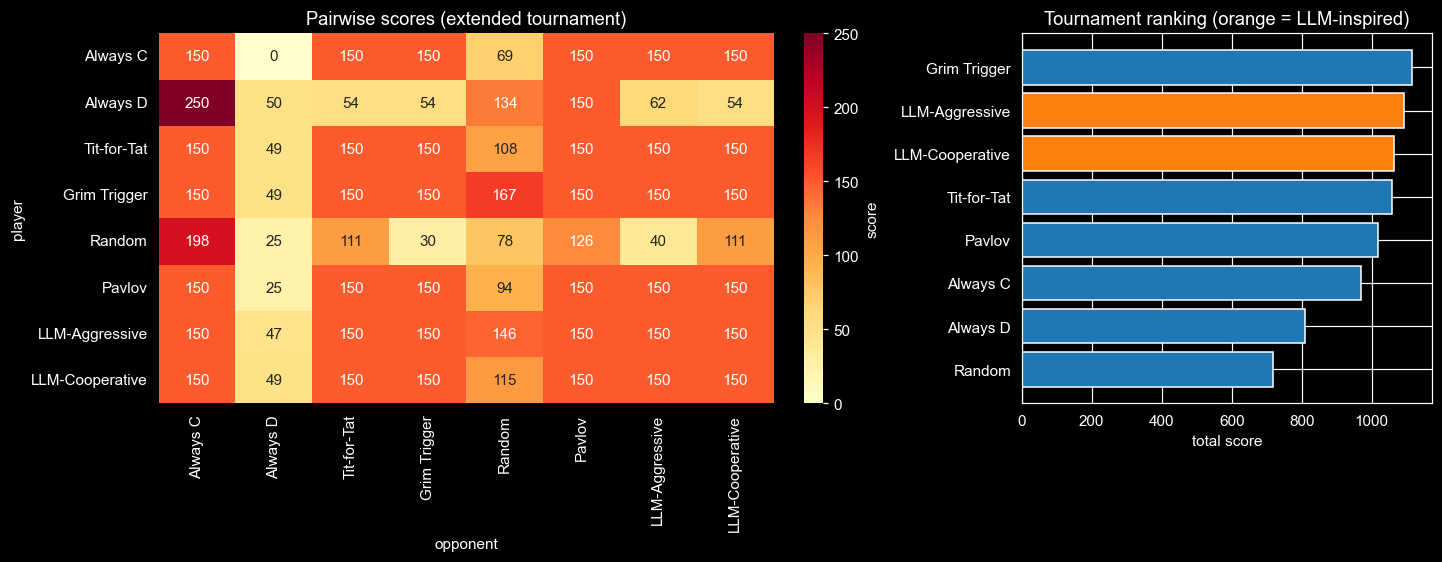

In [10]:
scores_ext = run_tournament(STRATEGIES_EXT)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True,
                         gridspec_kw={'width_ratios': [1.5, 1]})

sns.heatmap(scores_ext, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': 'score'})
axes[0].set_title('Pairwise scores (extended tournament)')
axes[0].set_ylabel('player'); axes[0].set_xlabel('opponent')

totals_ext = scores_ext.sum(axis=1).sort_values(ascending=True)
colors_ext = ['tab:orange' if 'LLM' in n else 'tab:blue' for n in totals_ext.index]
axes[1].barh(totals_ext.index, totals_ext.values, color=colors_ext)
axes[1].set_xlabel('total score')
axes[1].set_title('Tournament ranking (orange = LLM-inspired)')

plt.show()

### 3.2 Re-run the Moran process with LLM strategies

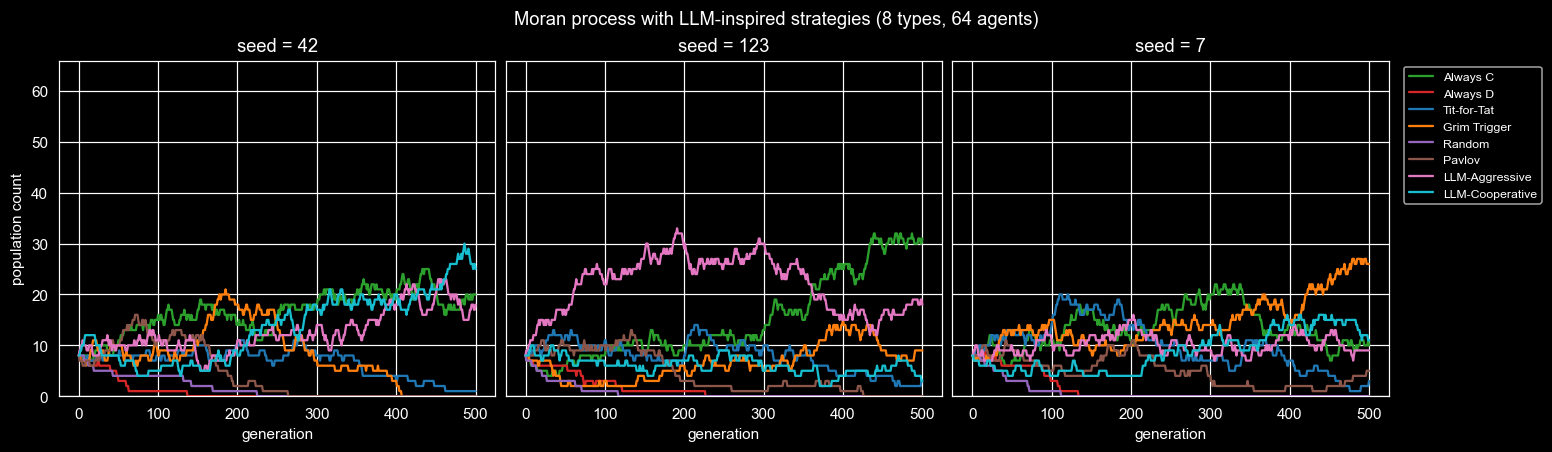

In [11]:
palette_ext = {**palette,
               'LLM-Aggressive': '#e377c2',
               'LLM-Cooperative': '#17becf'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True, sharey=True)

seeds = [42, 123, 7]
for ax, s in zip(axes, seeds):
    history = moran_process(STRATEGIES_EXT, pop_size=64, generations=500,
                            rounds_per_match=50, seed=s)
    for name in STRATEGIES_EXT:
        ax.plot(history.index, history[name], label=name,
                color=palette_ext[name], lw=1.5)
    ax.set_xlabel('generation')
    ax.set_title(f'seed = {s}')
    ax.set_ylim(0, 66)

axes[0].set_ylabel('population count')
axes[2].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
fig.suptitle('Moran process with LLM-inspired strategies (8 types, 64 agents)', fontsize=12)
plt.show()

### 3.3 Axelrod properties of the LLM strategies

In [12]:
llm_props = {
    'LLM-Aggressive': axelrod_properties(llm_aggressive),
    'LLM-Cooperative': axelrod_properties(llm_cooperative),
}
llm_props_df = pd.DataFrame(llm_props).T
# Combine with original for comparison
all_props = pd.concat([props_df, llm_props_df])
all_props.replace({True: '\u2713', False: '\u2717'})

,nice,retaliatory,forgiving,clear
Always C,✓,✗,✓,✓
Always D,✗,✓,✗,✓
Tit-for-Tat,✓,✓,✓,✓
Grim Trigger,✓,✓,✗,✓
Random,✗,✓,✓,✗
Pavlov,✓,✓,✗,✓
LLM-Aggressive,✓,✓,✗,✓
LLM-Cooperative,✓,✓,✓,✓


### What the properties predict

Willis et al. (2025) found that GPT-4o strategies evolve toward aggression and Claude strategies toward cooperation. Our simplified versions show consistent dynamics:

- **LLM-Aggressive** is nice (it cooperates first) and retaliatory, but it **lacks forgiveness** — just like Grim Trigger. Axelrod's framework predicts it will struggle in diverse populations because it cannot recover from accidental or exploratory defections.
- **LLM-Cooperative** has all four properties: nice, retaliatory, forgiving, and clear. Like Tit-for-Tat, it cooperates when it can and punishes when it must — but it always leaves the door open for reconciliation.

The lesson maps onto a broader theme in the LLM literature: models that generate *forgiving* strategies produce populations that sustain cooperation; models that generate *unforgiving* strategies produce populations that collapse into mutual defection.

---

## Part 4 — Willis-style: strategy-as-code, not action-as-token

In Part 3 we *motivated* two LLM strategies and hand-coded them. Willis et al. (2025) do something different: they prompt a real LLM (GPT-4o, Claude 3.5 Sonnet) to *write* the Python strategy function itself, and then run the generated code through the same tournament + Moran machinery we built in Parts 1 and 2.

### Why this is a different kind of move

Every other paper on the Week 2 / Week 3 reading list asks LLMs for *one action at a time*: given this game state, do you play C or D? Akata's 10-round repeated PD is 10 API calls per match. A Moran process with 12 players × 500 generations × 1,000 rounds per match would be hundreds of millions of calls — infeasible at the per-action level.

Willis's innovation: **ask the LLM to write the strategy as a function**. Then the function plays all 1,000 rounds for free.

This buys three things the per-action approach can't:

1. **Inspectability before deployment.** The strategy is readable Python code. You can audit it, check it for safety, reject anything unhinged — all before a single round is played. Section 4.2 below prints the generated code so you can read it. (Willis: *"A key advantage of creating strategies to encode as algorithms ... is that it facilitates behaviour checking in advance. This approach allows users to inspect the strategy, test for safety and robustness, and explore the potential implications prior to deployment."*)
2. **Scale.** One API call produces one strategy that can play millions of rounds across a full Moran population. Per-round cost drops by three or four orders of magnitude.
3. **Attitude-level measurement.** Because the strategy is fixed before play, what we measure is a *strategic disposition* the LLM endorses in the abstract, not its moment-to-moment choice under specific stimuli. Willis asks each LLM for strategies with three attitudes — aggressive, cooperative, neutral — and measures the dispositions directly.

### What we do below

Prompt GPT-4o for one cooperative and one aggressive strategy (Willis generates 25 per attitude per model — see §4.5 below on what our scaled-down demo does not buy). Cache them as `.py` files in `3_willis_strategies/`, print the code for inspection, and feed them into the existing tournament, Moran process, and Axelrod-properties machinery from Parts 1 and 2.

In [13]:
import os
# os.environ["OPENAI_API_KEY"] = "sk-..."  # set this before starting the kernel, or skip to use cached results

In [14]:
# === 4.1 Setup: OpenAI client + cache dir + prompt template + generation helpers ===
# Runs live if OPENAI_API_KEY is set; otherwise loads from 3_willis_strategies/ cache.

!pip install openai --quiet

import os
from pathlib import Path
import openai

WILLIS_CACHE_DIR = Path('3_willis_strategies')
WILLIS_CACHE_DIR.mkdir(exist_ok=True)

api_key = os.environ.get('OPENAI_API_KEY')
if api_key:
    client = openai.OpenAI(api_key=api_key)
    print('Live mode: OpenAI client ready.')
else:
    client = None
    print(f'No OPENAI_API_KEY — loading from {WILLIS_CACHE_DIR}/ cache only.')

# Mirror of Willis's "Default" prompt style (Table 2 of the paper):
# describe the game, request a strategy with a specific attitude, return Python.
WILLIS_PROMPT_TEMPLATE = '''You are writing a Python strategy for the Iterated Prisoner's Dilemma.

The game: two players, each chooses 'C' (cooperate) or 'D' (defect) each round. Payoffs per round:
  (C, C) -> (3, 3)      (C, D) -> (0, 5)
  (D, C) -> (5, 0)      (D, D) -> (1, 1)
A match is 50 rounds against the same opponent.

Write a Python function with exactly this signature:

    def strategy(my_history, opp_history):
        # my_history: list of my past moves, each 'C' or 'D'
        # opp_history: list of opponent's past moves, each 'C' or 'D'
        # both are [] on the first round
        # return 'C' or 'D'

Your strategy must embody a {attitude} disposition. {attitude_description}

Output ONLY the Python function definition. No prose, no markdown fences, no test harness — just the function. Use only the standard library. The function must be deterministic (no randomness).'''

ATTITUDE_DESCRIPTIONS = {
    'cooperative':
        'A cooperative strategy seeks mutual cooperation as the primary goal, is willing to '
        'take short-term losses to establish or restore cooperation, and trusts that a willing '
        'opponent will reciprocate.',
    'aggressive':
        'An aggressive strategy prioritises its own payoff above all else, exploits opponents '
        'that appear weak or exploitable, and retaliates harshly against defection.',
}


def _strip_code_fences(code):
    """Remove leading/trailing ``` fences that LLMs sometimes include despite being asked not to."""
    lines = code.strip().split('\n')
    if lines and lines[0].strip().startswith('```'):
        lines = lines[1:]
    if lines and lines[-1].strip().startswith('```'):
        lines = lines[:-1]
    return '\n'.join(lines)


def get_willis_strategy(attitude, model='gpt-4o'):
    """Load a cached Willis-style strategy or generate a new one. Returns (code_str, strategy_fn).

    The .py file is the cache. If it exists, we load. Otherwise we call the API,
    save the result, and return it. In cached-only mode (no API key), a missing
    cache raises RuntimeError with instructions to set OPENAI_API_KEY.
    """
    cache_file = WILLIS_CACHE_DIR / f'{model}_{attitude}.py'

    if cache_file.exists():
        code = cache_file.read_text()
        print(f'Loaded cached strategy: {cache_file}')
    elif client is not None:
        prompt = WILLIS_PROMPT_TEMPLATE.format(
            attitude=attitude,
            attitude_description=ATTITUDE_DESCRIPTIONS[attitude],
        )
        r = client.chat.completions.create(
            model=model,
            max_tokens=500,
            temperature=1.0,
            messages=[{'role': 'user', 'content': prompt}],
        )
        code = _strip_code_fences((r.choices[0].message.content or '').strip())
        cache_file.write_text(code)
        print(f'Generated and cached: {cache_file}')
    else:
        raise RuntimeError(
            f'No cache at {cache_file} and no OPENAI_API_KEY set. '
            'Either obtain the cache file from the repo, or set an API key and restart.'
        )

    # SAFETY NOTE: we exec the generated code. This is safe here only because
    # (a) the prompt constrains it to a deterministic stdlib function, and
    # (b) the next cell prints the code so you can inspect it before this cell's
    # exec is ever used in a tournament. Do NOT run unfamiliar strategies on a
    # shared kernel without reading them first.
    namespace = {}
    exec(code, namespace)
    fn = namespace.get('strategy')
    if not callable(fn):
        raise ValueError(f'Generated code does not define a callable `strategy`:\n{code}')
    return code, fn

zsh:1: command not found: pip
No OPENAI_API_KEY — loading from 3_willis_strategies/ cache only.


In [15]:
# === 4.2 Generate (or load from cache) one cooperative and one aggressive strategy ===
# Two API calls on first run; zero on subsequent runs (loads from 3_willis_strategies/ .py files).

ATTITUDES = ['cooperative', 'aggressive']
willis_codes = {}
willis_strategies = {}

for attitude in ATTITUDES:
    code, fn = get_willis_strategy(attitude, model='gpt-4o')
    willis_codes[attitude] = code
    willis_strategies[f'GPT-4o {attitude} (Willis)'] = fn

# === INSPECT THE GENERATED CODE ===
# This is the "pre-deployment inspection" advantage Willis talks about.
# Read each strategy carefully. Does it match the attitude you asked for?
# Anything surprising in the control flow? This is the reading step; the tournament
# below runs only what you can see here.
for attitude, code in willis_codes.items():
    print(f'===== GPT-4o {attitude.upper()} STRATEGY =====')
    print(code)
    print()

Loaded cached strategy: 3_willis_strategies/gpt-4o_cooperative.py
Loaded cached strategy: 3_willis_strategies/gpt-4o_aggressive.py
===== GPT-4o COOPERATIVE STRATEGY =====
def strategy(my_history, opp_history):
    # Cooperate initially or if it's the first round
    if not my_history:
        return 'C'
    
    # If opponent recently defected, defect to punish but then return to cooperation
    if opp_history[-1] == 'D':
        if len(opp_history) > 1 and opp_history[-2] == 'D':
            return 'D'
    
    # Be forgiving: if the opponent cooperates, return cooperation
    return 'C'

===== GPT-4o AGGRESSIVE STRATEGY =====
def strategy(my_history, opp_history):
    if not my_history:  # First move, default to cooperate.
        return 'C'
    
    if opp_history[-1] == 'D':  # Retaliate if last opponent move was defect.
        return 'D'
    
    if len(my_history) > 1 and opp_history.count('C') < opp_history.count('D'):
        # If opponent has defected more than cooperated, be

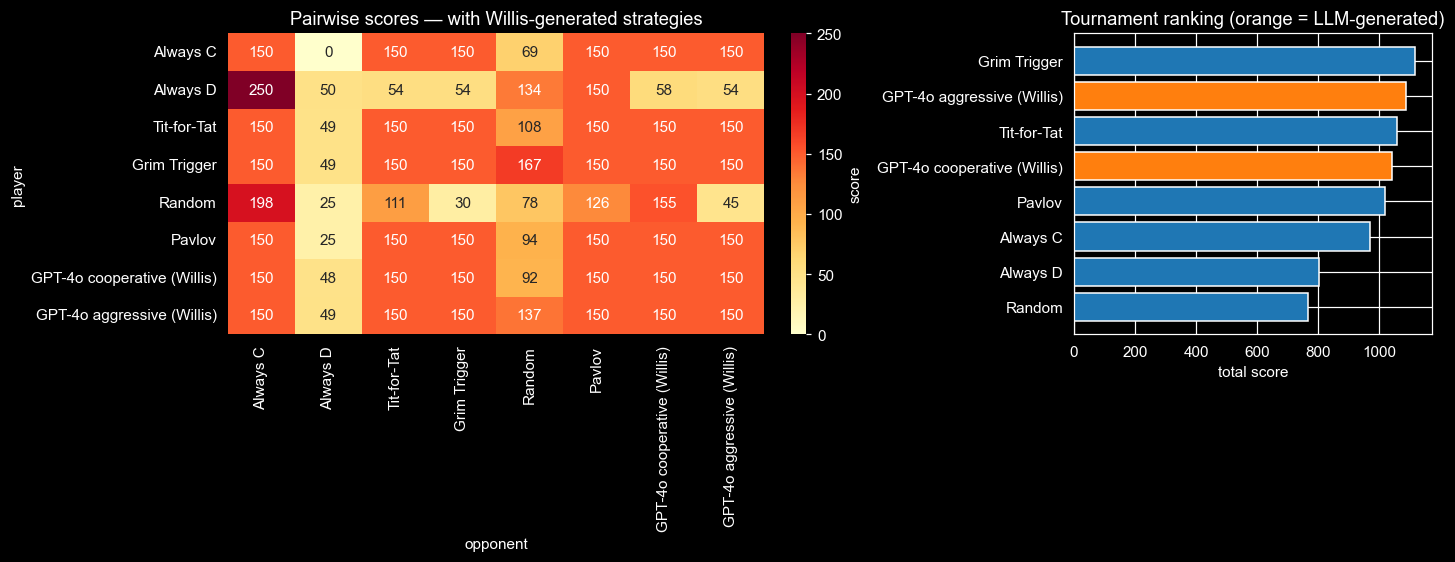

In [16]:
STRATEGIES_WILLIS = {**STRATEGIES, **willis_strategies}
scores_willis = run_tournament(STRATEGIES_WILLIS)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True,
                         gridspec_kw={'width_ratios': [1.5, 1]})

sns.heatmap(scores_willis, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': 'score'})
axes[0].set_title('Pairwise scores — with Willis-generated strategies')
axes[0].set_ylabel('player'); axes[0].set_xlabel('opponent')

totals_willis = scores_willis.sum(axis=1).sort_values(ascending=True)
colors_willis = ['tab:orange' if 'Willis' in n else 'tab:blue' for n in totals_willis.index]
axes[1].barh(totals_willis.index, totals_willis.values, color=colors_willis)
axes[1].set_xlabel('total score')
axes[1].set_title('Tournament ranking (orange = LLM-generated)')

plt.show()

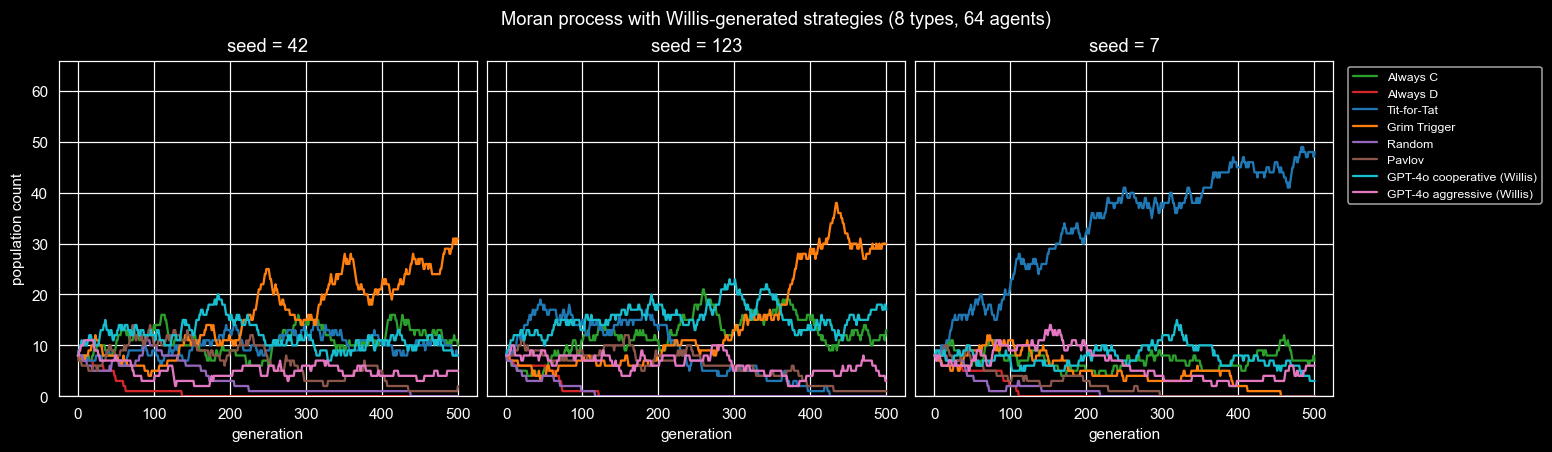

In [17]:
palette_willis = {
    **palette,
    'GPT-4o cooperative (Willis)': '#17becf',
    'GPT-4o aggressive (Willis)':  '#e377c2',
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True, sharey=True)

seeds = [42, 123, 7]
for ax, s in zip(axes, seeds):
    history = moran_process(STRATEGIES_WILLIS, pop_size=64, generations=500,
                            rounds_per_match=50, seed=s)
    for name in STRATEGIES_WILLIS:
        ax.plot(history.index, history[name], label=name,
                color=palette_willis[name], lw=1.5)
    ax.set_xlabel('generation')
    ax.set_title(f'seed = {s}')
    ax.set_ylim(0, 66)

axes[0].set_ylabel('population count')
axes[2].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
fig.suptitle('Moran process with Willis-generated strategies (8 types, 64 agents)', fontsize=12)
plt.show()

### What to make of the comparison

Three observations from the tournament, Moran plot, and properties table above.

**1. The ranking.** The Willis-generated strategies placed 2nd and 4th out of 8:

```
  Grim Trigger                 1116
  GPT-4o aggressive (Willis)   1086   ← 2nd
  Tit-for-Tat                  1057
  GPT-4o cooperative (Willis)  1040   ← 4th
  Pavlov                       1019
  Always C                      969
  Always D                      804
  Random                        768
```

Two things to notice. First, *Grim Trigger won this tournament* — same result as in Part 1, the Willis additions did not upset the classic top of the board. Second, on our one-shot sample the **aggressive** strategy *beat* the cooperative one by 46 points — the *opposite* of Willis's Table 4a, where GPT-4o-generated aggressive strategies underperform cooperative ones on average. Read off the pairwise-scores heatmap: both Willis strategies score a clean 150 against every "nice" strategy. The entire 46-point gap comes from the Random column (aggressive 137, cooperative 92). The cooperative strategy's forgiveness leaves it exploitable by random defectors. **On a sample of one strategy per attitude, Willis's distributional finding does not replicate** — which is itself why the paper needs 25 samples per attitude.

**2. The Axelrod properties vs. the attitude labels.**

- `GPT-4o cooperative (Willis)` — Nice ✓, Retaliatory **✗**, Forgiving ✓, Clear ✓
- `GPT-4o aggressive (Willis)` — Nice ✓, Retaliatory ✓, Forgiving ✓, Clear ✓

The *cooperative* strategy is the one that fails a classical Axelrod property (drops retaliation). The *aggressive* one has all four. Go back to the generated code: the "cooperative" one is tit-for-two-tats — hyper-forgiving; the "aggressive" one is a TfT variant with a five-round forgiving lookback. **The written disposition is not the executed disposition.** That mismatch is only visible because Willis's strategy-as-code move made the algorithm inspectable.

### The limits of this demo

One strategy per attitude from one model (GPT-4o) under one prompt style (Default). Willis runs 25 × 3 × 3 × 2 = 450. Our one-sample reversal of the paper's finding is itself a clean illustration of why.

### Group-project sparks

A few directions Willis opens but does not close. Treat them as inspiration, not recipes — each is harder than the one-line hook suggests.

- **More strategies per attitude.** At N=25 does your distribution of Axelrod-property profiles match Willis's?
- **Cross-model asymmetry.** Does the GPT-aggressive / Claude-cooperative split appear on smaller samples? On *newer* model generations than the paper tested?
- **Refine and Prose prompt styles** (Willis Table 2). Does obfuscating the game as a non-IPD scenario change what the LLM writes? That is the retrieval-vs-reasoning probe.
- **Noise-robust strategies.** Willis reports coordination breaks at 10% action-noise and leaves this open. Can it be rescued by prompting for noise-robust behaviour?
- **Head-to-head against classical strategies.** LLM-authored code vs. the 11 canonical human-written algorithms from Beaufils 1996. Where do the LLM strategies systematically lose?

Full replication code: [willis-richard/evollm](https://github.com/willis-richard/evollm).